In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [35]:
#loading data
dataset = pd.read_csv(r'C:\Users\Spandan Dutta\econometrics_project\data\processed\master_panel.csv',parse_dates=['date'], index_col = 'date')

In [36]:
# Summary
summary = (dataset.filter(['yield_2y','yield_5y','yield_10y','yield_30y','slope_10y_2y','fpi','us_10y','vix','brent','repo_rate','cpi_inflation']).describe().round(2))
print(summary)
summary.to_csv(r'C:\Users\Spandan Dutta\econometrics_project\outputs\tables\summary_statistics.csv')

       yield_2y  yield_5y  yield_10y  yield_30y  slope_10y_2y    fpi  us_10y  \
count     58.00     58.00      58.00      58.00         58.00  54.00   58.00   
mean       6.23      6.67       6.89       7.22          0.66   2.01    3.50   
std        0.95      0.54       0.38       0.22          0.67   0.59    1.08   
min        4.22      5.66       6.22       6.76         -0.04   1.31    1.24   
25%        5.72      6.23       6.62       7.06          0.13   1.53    2.91   
50%        6.67      6.79       6.87       7.21          0.35   1.80    3.94   
75%        7.00      7.16       7.20       7.39          0.92   2.61    4.24   
max        7.34      7.48       7.48       7.71          2.15   3.12    4.88   

         vix   brent  repo_rate  cpi_inflation  
count  58.00   58.00      58.00          39.00  
mean   19.07   81.50       5.69           4.92  
std     4.64   13.37       1.01           1.31  
min    12.67   62.54       4.00           2.15  
25%    15.86   73.34       4.90   

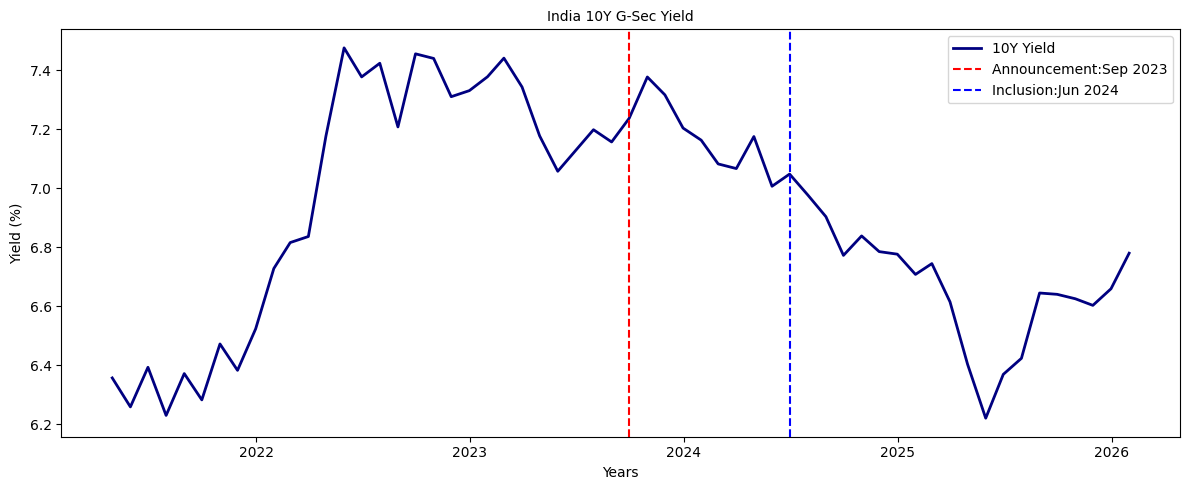

In [22]:
#10 Year yield
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(dataset.index, dataset['yield_10y'],
        color='navy', linewidth=2, label='10Y Yield')

ax.axvline(pd.Timestamp('2023-09-30'), color='red',
           linestyle='--', linewidth=1.5, label='Announcement:Sep 2023')
ax.axvline(pd.Timestamp('2024-06-30'), color='blue',
           linestyle='--', linewidth=1.5, label='Inclusion:Jun 2024')

ax.set_title('India 10Y G-Sec Yield', fontsize=10)
ax.set_ylabel('Yield (%)')
ax.set_xlabel('Years')
ax.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\Spandan Dutta\econometrics_project\outputs\figures\01_10_year_yield.png')

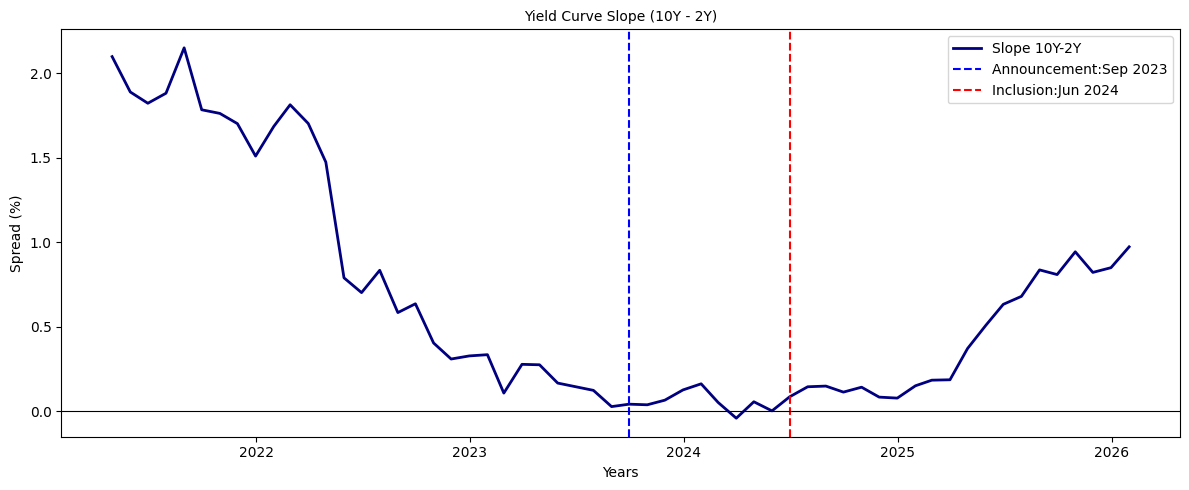

In [23]:
#2 yield curve slope
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(dataset.index, dataset['slope_10y_2y'],
        color='navy', linewidth=2, label='Slope 10Y-2Y')

ax.axvline(pd.Timestamp('2023-09-30'), color='blue',
           linestyle='--', linewidth=1.5, label='Announcement:Sep 2023')
ax.axvline(pd.Timestamp('2024-06-30'), color='red',
           linestyle='--', linewidth=1.5, label='Inclusion:Jun 2024')
ax.axhline(0, color='black', linewidth=0.8, linestyle='-')

ax.set_title('Yield Curve Slope (10Y - 2Y)', fontsize=10)
ax.set_ylabel('Spread (%)')
ax.set_xlabel('Years')
ax.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\Spandan Dutta\econometrics_project\outputs\figures\02_slope.png', dpi=150)
plt.show()

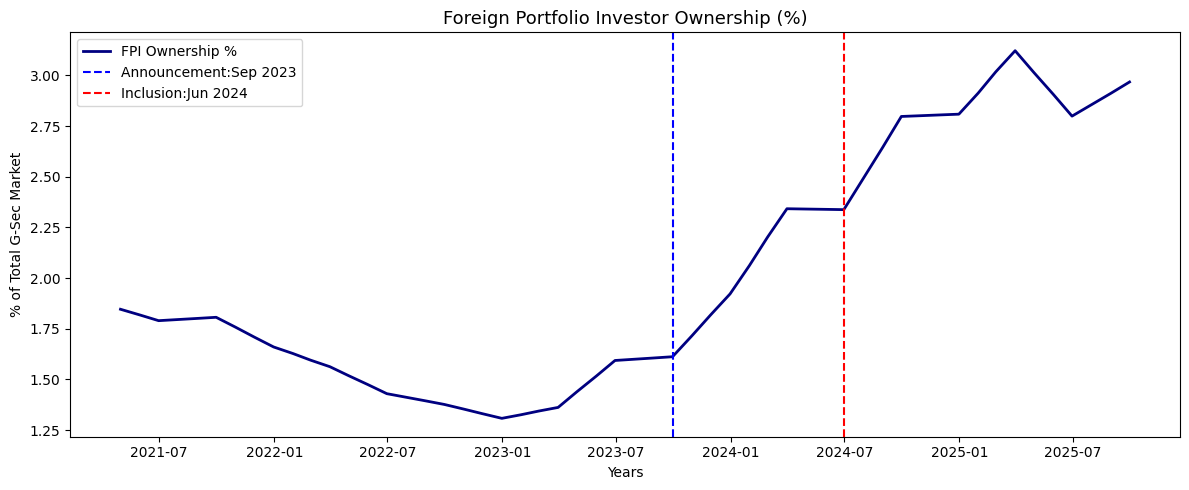

In [24]:
#FPI
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(dataset.index, dataset['fpi'],
        color='navy', linewidth=2, label='FPI Ownership %')

ax.axvline(pd.Timestamp('2023-09-30'), color='blue',
           linestyle='--', linewidth=1.5, label='Announcement:Sep 2023')
ax.axvline(pd.Timestamp('2024-06-30'), color='red',
           linestyle='--', linewidth=1.5, label='Inclusion:Jun 2024')

ax.set_title('Foreign Portfolio Investor Ownership (%)', fontsize=13)
ax.set_ylabel('% of Total G-Sec Market')
ax.set_xlabel('Years')
ax.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\Spandan Dutta\econometrics_project\outputs\figures\03_fpi_ownership.png', dpi=150)
plt.show()

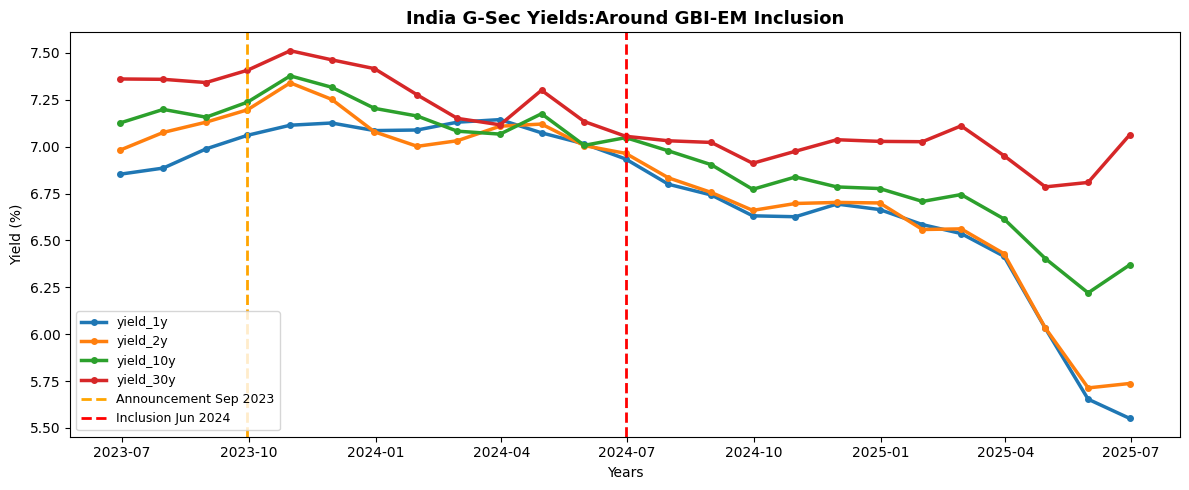

In [55]:
cols = ["yield_1y", "yield_2y", "yield_10y", "yield_30y"]

df = dataset.copy()
df.index = pd.to_datetime(df.index, errors="coerce")
df = df[df.index.notna()].sort_index()
df = df[(df.index >= "2023-06-01") & 
        (df.index <= "2025-06-30")]
for c in cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
plt.figure(figsize=(12, 5))
for c in cols:
    plt.plot(df.index, df[c], linewidth=2.5, label=c, marker='o', markersize=4)
plt.axvline(pd.Timestamp("2023-09-30"), color="orange",
            linestyle="--", linewidth=2,
            label="Announcement Sep 2023")
plt.axvline(pd.Timestamp("2024-06-30"), color="red",
            linestyle="--", linewidth=2,
            label="Inclusion Jun 2024")
plt.title("India G-Sec Yields:Around GBI-EM Inclusion",
          fontweight='bold', fontsize=13)
plt.ylabel("Yield (%)")
plt.xlabel("Years")
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig(r'C:\Users\Spandan Dutta\econometrics_project\outputs\figures\04_India_GSEC_yield.png', dpi=150)
plt.show()

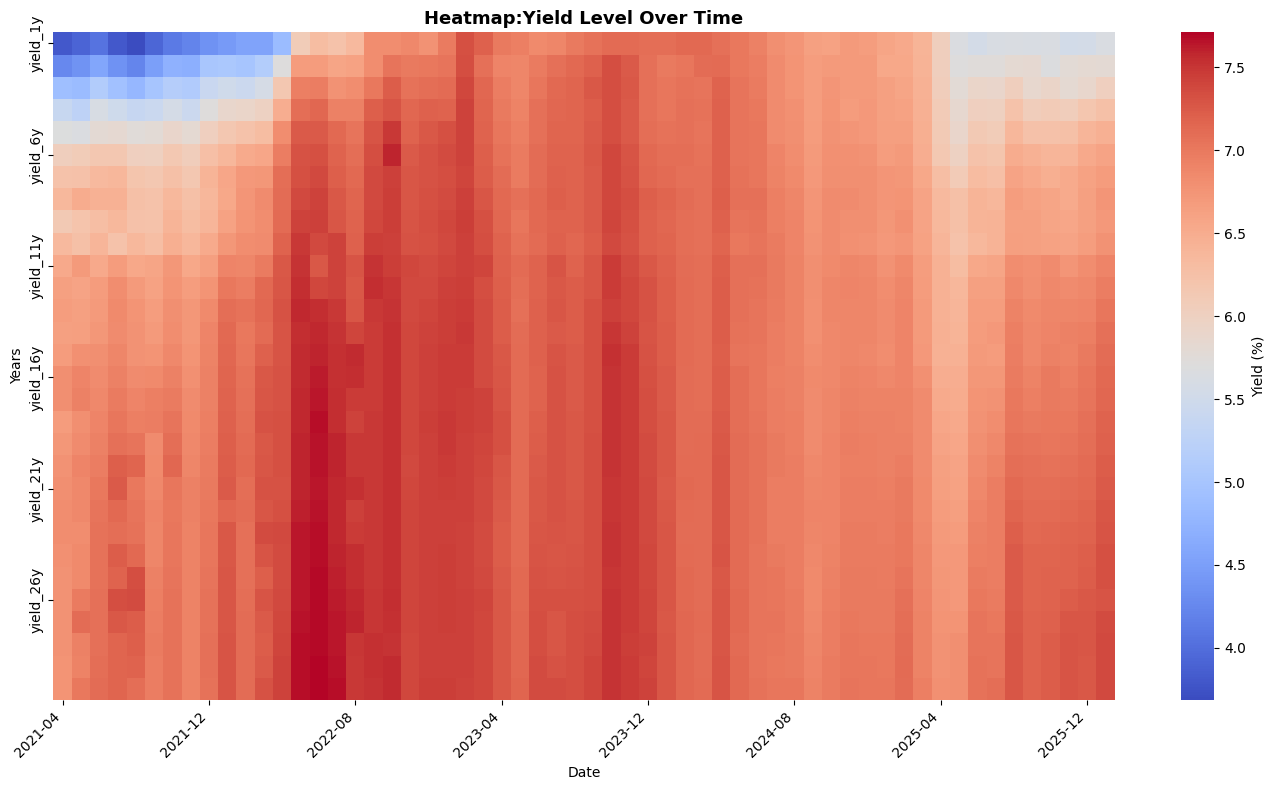

In [59]:
#heat map for all tenors
dataset = pd.read_csv(r'C:\Users\Spandan Dutta\econometrics_project\data\processed\master_panel.csv',parse_dates=['date'],index_col='date')
tenors_all  = [f'yield_{t}y' for t in range(1, 31)]
heat_data   = dataset[tenors_all].T
date_labels = dataset.index.strftime('%Y-%m')

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(heat_data,cmap='coolwarm',ax=ax,xticklabels=8,yticklabels=5,cbar_kws={'label': 'Yield (%)'})
ax.set_xticklabels(date_labels[::8], rotation=45, ha='right')
ax.set_title('Heatmap:Yield Level Over Time',fontweight='bold', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Years')
plt.tight_layout()
plt.savefig(r'C:\Users\Spandan Dutta\econometrics_project\outputs\figures\05_heatmap_yield.png', dpi=150)
plt.show()


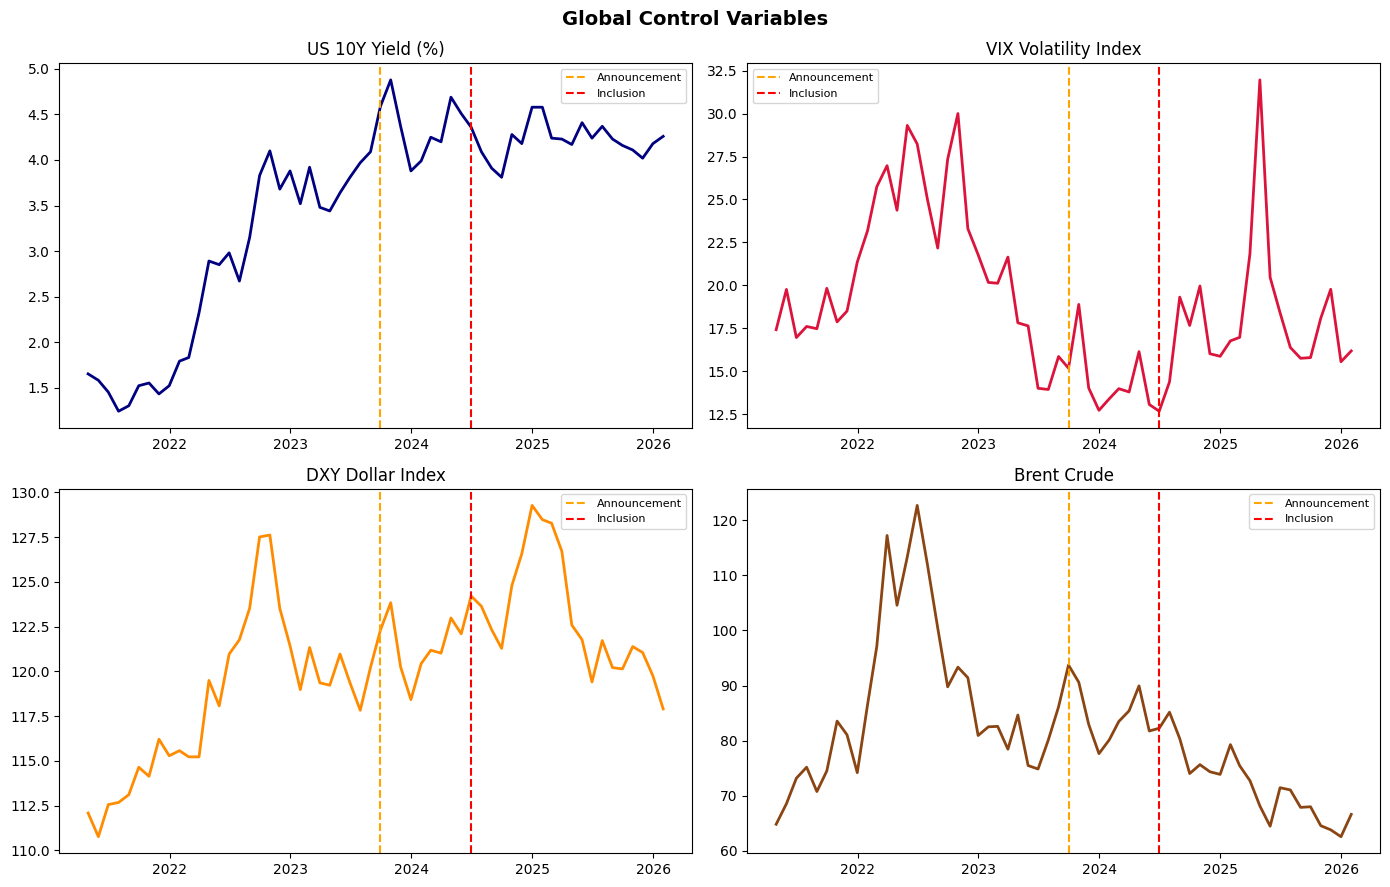

In [64]:
#Control variables
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Global Control Variables',fontsize=14, fontweight='bold')

# US 10Y
axes[0,0].plot(dataset.index, dataset['us_10y'],color='navy', linewidth=2)
axes[0,0].axvline(pd.Timestamp('2023-09-30'), color='orange',linestyle='--', linewidth=1.5, label='Announcement')
axes[0,0].axvline(pd.Timestamp('2024-06-30'), color='red',linestyle='--', linewidth=1.5, label='Inclusion')
axes[0,0].set_title('US 10Y Yield (%)')
axes[0,0].legend(fontsize=8)

# VIX
axes[0,1].plot(dataset.index, dataset['vix'],color='crimson', linewidth=2)
axes[0,1].axvline(pd.Timestamp('2023-09-30'), color='orange',linestyle='--', linewidth=1.5, label='Announcement')
axes[0,1].axvline(pd.Timestamp('2024-06-30'), color='red',linestyle='--', linewidth=1.5, label='Inclusion')
axes[0,1].set_title('VIX Volatility Index')
axes[0,1].legend(fontsize=8)

# DXY
axes[1,0].plot(dataset.index, dataset['dxy'],color='darkorange', linewidth=2)
axes[1,0].axvline(pd.Timestamp('2023-09-30'), color='orange',linestyle='--', linewidth=1.5, label='Announcement')
axes[1,0].axvline(pd.Timestamp('2024-06-30'), color='red',linestyle='--', linewidth=1.5, label='Inclusion')
axes[1,0].set_title('DXY Dollar Index')
axes[1,0].legend(fontsize=8)

# Brent
axes[1,1].plot(dataset.index, dataset['brent'],color='saddlebrown', linewidth=2)
axes[1,1].axvline(pd.Timestamp('2023-09-30'), color='orange',linestyle='--', linewidth=1.5, label='Announcement')
axes[1,1].axvline(pd.Timestamp('2024-06-30'), color='red',linestyle='--', linewidth=1.5, label='Inclusion')
axes[1,1].set_title('Brent Crude')
axes[1,1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(r'C:\Users\Spandan Dutta\econometrics_project\outputs\figures\06_global_control_variables.png', dpi=150)
plt.show()


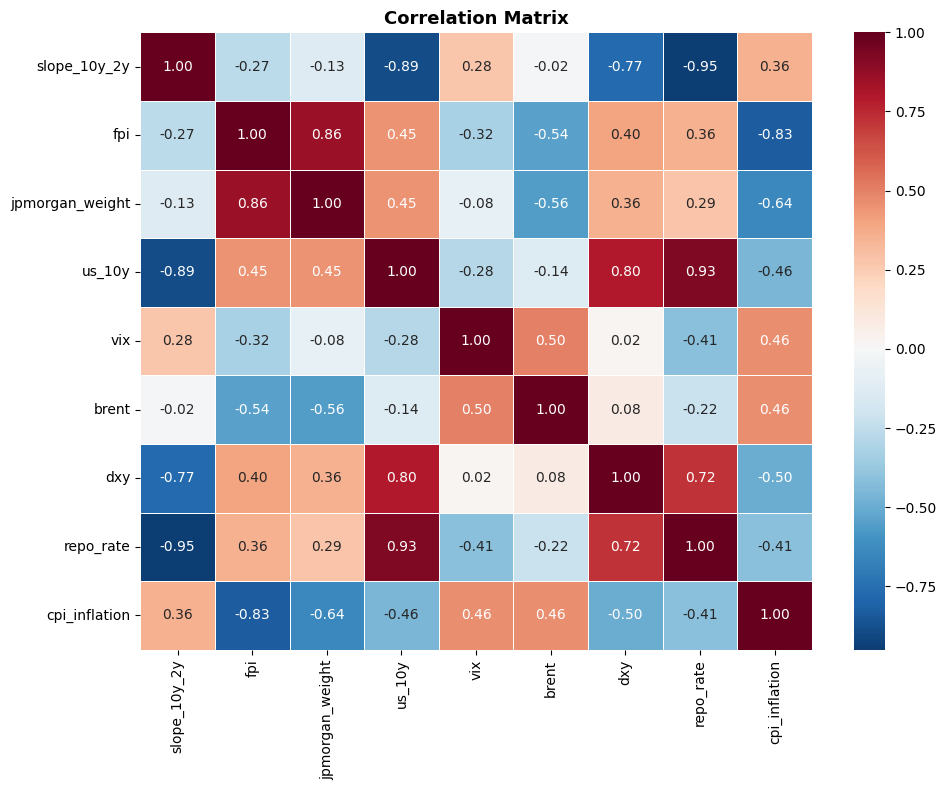

In [68]:
#variables for correlation
corr_vars = ['slope_10y_2y','fpi','jpmorgan_weight','us_10y','vix','brent','dxy','repo_rate','cpi_inflation']

#correlation matrix
corr = dataset[corr_vars].corr().round(2)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr,annot=True,cmap='RdBu_r',center=0,fmt='.2f',linewidths=0.5,ax=ax)
ax.set_title('Correlation Matrix',fontweight='bold', fontsize=13)
plt.savefig(r'C:\Users\Spandan Dutta\econometrics_project\outputs\figures\07_corr_heatmap.png', dpi=150)
plt.tight_layout()
plt.show()



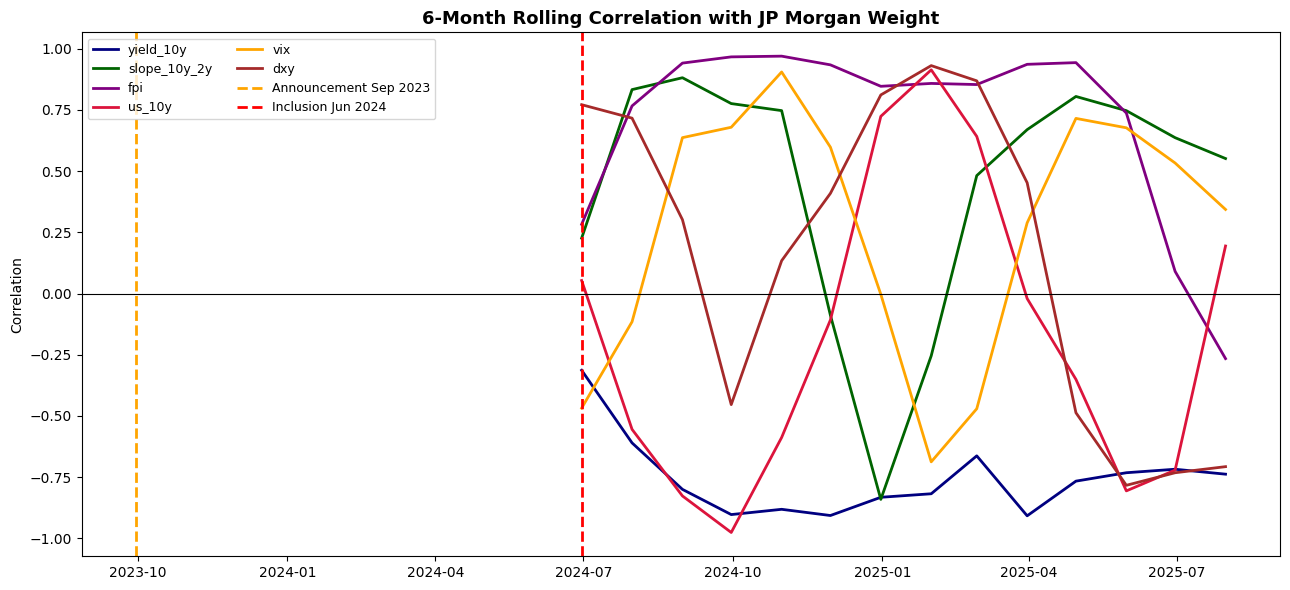

In [73]:
#rolling correlation with jp morgan weight
roll_cols = {
    'yield_10y':'navy',
    'slope_10y_2y':'darkgreen',
    'fpi':'purple',
    'us_10y':'crimson',
    'vix':'orange',
    'dxy':'brown',
}
# rolling correlations in one dictionary comprehension
roll_corr = pd.DataFrame({col: dataset['jpmorgan_weight'].rolling(6).corr(dataset[col])for col in roll_cols})
fig, ax = plt.subplots(figsize=(13, 6))
for col, color in roll_cols.items():
    ax.plot(roll_corr.index, roll_corr[col], linewidth=2, color=color, label=col)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(pd.Timestamp('2023-09-30'), color='orange',linestyle='--', linewidth=2,label='Announcement Sep 2023')
ax.axvline(pd.Timestamp('2024-06-30'), color='red',linestyle='--', linewidth=2,label='Inclusion Jun 2024')
ax.set_title('6-Month Rolling Correlation with JP Morgan Weight',fontweight='bold', fontsize=13)
ax.set_ylabel('Correlation')
ax.legend(fontsize=9, ncols=2)
plt.tight_layout()
plt.savefig(r'C:\Users\Spandan Dutta\econometrics_project\outputs\figures\rolling_correlation.png',dpi=150)
plt.show()